
[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Запуск приложения...
Ошибка в обучении: Given groups=1, weight of size [1, 1, 5, 5], expected input[4, 3, 480, 640] to have 1 channels, but got 3 channels instead
Ошибка в обучении: Given groups=1, weight of size [1, 1, 5, 5], expected input[5, 3, 480, 640] to have 1 channels, but got 3 channels instead
Ошибка в обучении: Given groups=1, weight of size [1, 1, 5, 5], expected input[6, 3, 480, 640] to have 1 channels, but got 3 channels instead
Ошибка в обучении: Given groups=1, weight of size [1, 1, 5, 5], expected input[7, 3, 480, 640] to have 1 channels, but got 3 channels instead
Ошибка в обучении: Given groups=1, weight of size [1, 1, 5, 5], expected input[8, 3, 480, 640] to have 1 channels, but got 3 channels instead
Ошибка в обучении: Given groups=1, weight of size [1, 1, 5, 5], expected input[8, 3, 480, 640] to have 1 channels, but got 3 channels instead
Ошибка в обучении: Given groups=1, weight of size [1, 1, 5, 5], expected input[8, 3, 480, 640] to have 1 channels, but got 3 ch

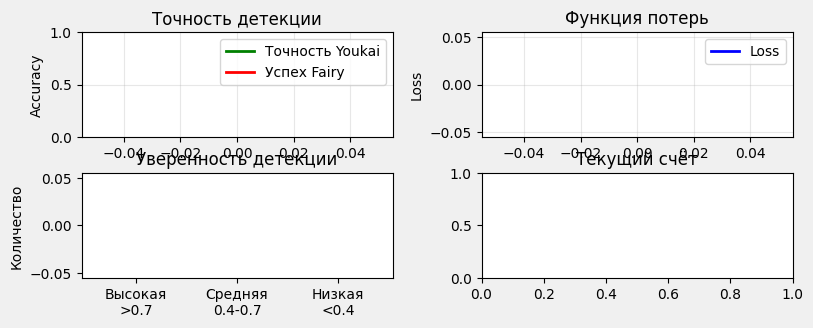

Ошибка в обучении: Given groups=1, weight of size [1, 1, 5, 5], expected input[8, 3, 480, 640] to have 1 channels, but got 3 channels instead
Ошибка в обучении: Given groups=1, weight of size [1, 1, 5, 5], expected input[8, 3, 480, 640] to have 1 channels, but got 3 channels instead
Ошибка в обучении: Given groups=1, weight of size [1, 1, 5, 5], expected input[8, 3, 480, 640] to have 1 channels, but got 3 channels instead
Ошибка в обучении: Given groups=1, weight of size [1, 1, 5, 5], expected input[8, 3, 480, 640] to have 1 channels, but got 3 channels instead
Ошибка в обучении: Given groups=1, weight of size [1, 1, 5, 5], expected input[8, 3, 480, 640] to have 1 channels, but got 3 channels instead
Ошибка в обучении: Given groups=1, weight of size [1, 1, 5, 5], expected input[8, 3, 480, 640] to have 1 channels, but got 3 channels instead
Ошибка в обучении: Given groups=1, weight of size [1, 1, 5, 5], expected input[8, 3, 480, 640] to have 1 channels, but got 3 channels instead
Ошибка

In [ ]:
# %% [markdown]
# # Нейросетевая игра в прятки: Fairy vs Youkai (ФИНАЛЬНАЯ СТАБИЛЬНАЯ ВЕРСИЯ)

# %% [markdown]
# ### Установка необходимых библиотек

# %%
!pip install torch torchvision opencv-python pillow numpy matplotlib

# %% [markdown]
# ### Импорт всех зависимостей

# %%
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import cv2
import numpy as np
from PIL import Image, ImageTk
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import tkinter as tk
from tkinter import ttk, filedialog, messagebox
import threading
import time
from collections import deque
import random
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# %% [markdown]
# ### 1. Определение архитектур нейросетей

# %%
class Fairy(nn.Module):
    """Fairy - нейросеть-прятальщик"""
    def __init__(self, noise_dim=64):
        super(Fairy, self).__init__()
        self.noise_dim = noise_dim
        
        self.noise_generator = nn.Sequential(
            nn.Linear(noise_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )
        
        self.noise_amplitude = nn.Parameter(torch.tensor(0.1))
        self.shift_range = nn.Parameter(torch.tensor(0.05))
        self.blur_kernel = nn.Parameter(torch.tensor(3.0))
        
    def forward(self, x, training=True):
        if not training:
            return x
            
        batch_size, channels, h, w = x.shape
        
        noise_vector = torch.randn(batch_size, self.noise_dim).to(x.device)
        noise_params = self.noise_generator(noise_vector)
        
        noise_amp = torch.sigmoid(self.noise_amplitude) * 0.3
        noise_pattern = noise_params.view(batch_size, -1, 1, 1)
        noise = torch.randn_like(x) * noise_amp * torch.sigmoid(noise_pattern.mean())
        
        shift_x = (torch.rand(batch_size) - 0.5).to(x.device) * self.shift_range * 2
        shift_y = (torch.rand(batch_size) - 0.5).to(x.device) * self.shift_range * 2
        
        grid_y, grid_x = torch.meshgrid(
            torch.linspace(-1, 1, h, device=x.device),
            torch.linspace(-1, 1, w, device=x.device),
            indexing='ij'
        )
        grid_x = grid_x.unsqueeze(0) + shift_x.view(-1, 1, 1)
        grid_y = grid_y.unsqueeze(0) + shift_y.view(-1, 1, 1)
        grid = torch.stack([grid_x, grid_y], dim=-1)
        
        shifted = F.grid_sample(x, grid, align_corners=False, padding_mode='border')
        corrupted = shifted + noise
        
        blur_size = int(torch.sigmoid(self.blur_kernel) * 5)
        if blur_size % 2 == 0:
            blur_size += 1
        if blur_size > 1:
            kernel = torch.ones(1, 1, blur_size, blur_size).to(x.device) / (blur_size ** 2)
            corrupted = F.conv2d(corrupted, kernel, padding=blur_size//2)
        
        return torch.clamp(corrupted, 0, 1)


class Youkai(nn.Module):
    """Youkai - нейросеть-искатель"""
    def __init__(self, num_classes=3):
        super(Youkai, self).__init__()
        self.num_classes = num_classes
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        
        self.bbox_head = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 4, kernel_size=1)
        )
        
        self.class_head = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, num_classes, kernel_size=1)
        )
        
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
    def forward(self, x):
        features = self.features(x)
        
        bbox_raw = self.bbox_head(features)
        class_raw = self.class_head(features)
        
        bbox_out = self.global_pool(bbox_raw).squeeze(-1).squeeze(-1)
        class_out = self.global_pool(class_raw).squeeze(-1).squeeze(-1)
        
        bbox_out = torch.sigmoid(bbox_out)
        
        return bbox_out, class_out


class FairyYoukaiGame:
    """Основной класс игры двух нейросетей"""
    def __init__(self, num_classes=3, model_dir="saved_models"):
        self.num_classes = num_classes
        self.model_dir = model_dir
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        os.makedirs(model_dir, exist_ok=True)
        
        self.fairy = Fairy().to(self.device)
        self.youkai = Youkai(num_classes).to(self.device)
        
        self.fairy_optimizer = optim.Adam(self.fairy.parameters(), lr=0.0005)
        self.youkai_optimizer = optim.Adam(self.youkai.parameters(), lr=0.001)
        
        self.youkai_accuracy_history = deque(maxlen=500)
        self.fairy_success_history = deque(maxlen=500)
        self.loss_history = deque(maxlen=500)
        
        self.youkai_score = 0
        self.fairy_score = 0
        self.epoch = 0
        
    def save_models(self, filename=None):
        if filename is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f"fairy_youkai_{timestamp}.pth"
        
        filepath = os.path.join(self.model_dir, filename)
        
        checkpoint = {
            'epoch': self.epoch,
            'fairy_state_dict': self.fairy.state_dict(),
            'youkai_state_dict': self.youkai.state_dict(),
            'fairy_optimizer': self.fairy_optimizer.state_dict(),
            'youkai_optimizer': self.youkai_optimizer.state_dict(),
            'youkai_score': self.youkai_score,
            'fairy_score': self.fairy_score,
            'youkai_accuracy_history': list(self.youkai_accuracy_history),
            'fairy_success_history': list(self.fairy_success_history),
            'loss_history': list(self.loss_history)
        }
        
        torch.save(checkpoint, filepath)
        return filename
    
    def load_models(self, filename):
        filepath = os.path.join(self.model_dir, filename)
        
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Файл {filename} не найден")
        
        checkpoint = torch.load(filepath, map_location=self.device)
        
        self.fairy.load_state_dict(checkpoint['fairy_state_dict'])
        self.youkai.load_state_dict(checkpoint['youkai_state_dict'])
        self.fairy_optimizer.load_state_dict(checkpoint['fairy_optimizer'])
        self.youkai_optimizer.load_state_dict(checkpoint['youkai_optimizer'])
        
        self.epoch = checkpoint['epoch']
        self.youkai_score = checkpoint['youkai_score']
        self.fairy_score = checkpoint['fairy_score']
        self.youkai_accuracy_history = deque(checkpoint['youkai_accuracy_history'], maxlen=500)
        self.fairy_success_history = deque(checkpoint['fairy_success_history'], maxlen=500)
        self.loss_history = deque(checkpoint['loss_history'], maxlen=500)
        
        return checkpoint
    
    def list_saved_models(self):
        models = []
        for f in os.listdir(self.model_dir):
            if f.endswith('.pth'):
                models.append(f)
        return sorted(models, reverse=True)
    
    def reset_training(self):
        self.fairy = Fairy().to(self.device)
        self.youkai = Youkai(self.num_classes).to(self.device)
        
        self.fairy_optimizer = optim.Adam(self.fairy.parameters(), lr=0.0005)
        self.youkai_optimizer = optim.Adam(self.youkai.parameters(), lr=0.001)
        
        self.youkai_accuracy_history.clear()
        self.fairy_success_history.clear()
        self.loss_history.clear()
        
        self.youkai_score = 0
        self.fairy_score = 0
        self.epoch = 0
        
    def train_step(self, original_image):
        original_tensor = original_image.to(self.device)
        
        corrupted = self.fairy(original_tensor, training=True)
        bbox_pred, class_pred = self.youkai(corrupted)
        
        with torch.no_grad():
            bbox_orig, class_orig = self.youkai(original_tensor)
        
        consistency_loss = F.mse_loss(bbox_pred, bbox_orig) + F.mse_loss(class_pred, class_orig)
        confidence_loss = -torch.mean(torch.abs(class_pred - 0.5)) * 0.1
        
        youkai_loss = consistency_loss + confidence_loss
        fairy_loss = -consistency_loss + 0.01 * torch.mean(torch.abs(corrupted - original_tensor))
        
        self.youkai_optimizer.zero_grad()
        youkai_loss.backward(retain_graph=True)
        self.youkai_optimizer.step()
        
        self.fairy_optimizer.zero_grad()
        fairy_loss.backward()
        self.fairy_optimizer.step()
        
        accuracy = 1.0 - min(1.0, consistency_loss.item())
        self.youkai_accuracy_history.append(accuracy)
        self.fairy_success_history.append(1.0 - accuracy)
        self.loss_history.append(consistency_loss.item())
        
        if accuracy > 0.7:
            self.youkai_score += 1
        elif accuracy < 0.3:
            self.fairy_score += 1
            
        self.epoch += 1
        
        return {
            'youkai_loss': youkai_loss.item(),
            'fairy_loss': fairy_loss.item(),
            'accuracy': accuracy,
        }
    
    def detect_objects(self, image_tensor):
        with torch.no_grad():
            bbox, classes = self.youkai(image_tensor.to(self.device))
        return bbox.cpu(), classes.cpu()


# %% [markdown]
# ### 2. Главное приложение (исправленная версия)

# %%
class ObjectDetectionApp:
    def __init__(self):
        self.root = tk.Tk()
        self.root.title("Fairy vs Youkai - Нейросетевая игра в прятки")
        self.root.geometry("1600x950")
        
        # Инициализация
        self.game = FairyYoukaiGame(num_classes=3)
        self.class_names = ['Человек', 'Машина', 'Животное']
        
        # Переменные для видео
        self.cap = None
        self.is_running = True
        self.video_source = "synthetic"
        self.video_path = None
        self.use_synthetic_video = True
        
        # Для хранения ссылок на PhotoImage
        self.current_images = {}
        
        self.colors = [(0, 255, 0), (255, 0, 0), (0, 0, 255)]
        
        # Флаги
        self.updating = False
        self.gui_ready = False
        
        # Создание GUI
        self.setup_gui()
        
        # Запуск видео в отдельном потоке
        self.video_thread = None
        self.start_video()
        
        # Запуск обучения
        self.training_thread = threading.Thread(target=self.training_loop, daemon=True)
        self.training_thread.start()
        
    def setup_gui(self):
        """Создание интерфейса"""
        main_frame = ttk.Frame(self.root)
        main_frame.pack(fill=tk.BOTH, expand=True)
        
        # Панель инструментов
        toolbar = self.create_toolbar(main_frame)
        toolbar.pack(fill=tk.X, padx=10, pady=5)
        
        # Панель статуса
        self.status_frame = ttk.Frame(main_frame)
        self.status_frame.pack(fill=tk.X, padx=10, pady=5)
        
        self.status_label = ttk.Label(self.status_frame, text="Обучение: идёт...", font=('Arial', 10))
        self.status_label.pack(side=tk.LEFT, padx=10)
        
        self.score_label = ttk.Label(self.status_frame, text="Youkai 0 : 0 Fairy", font=('Arial', 10, 'bold'))
        self.score_label.pack(side=tk.RIGHT, padx=10)
        
        self.epoch_label = ttk.Label(self.status_frame, text="Шаг: 0", font=('Arial', 9))
        self.epoch_label.pack(side=tk.RIGHT, padx=10)
        
        # Основной контент - 4 области
        content_frame = ttk.Frame(main_frame)
        content_frame.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)
        
        # Верхняя строка
        top_frame = ttk.Frame(content_frame)
        top_frame.pack(fill=tk.BOTH, expand=True)
        
        # Часть 1
        left_top = ttk.LabelFrame(top_frame, text="1. Исходное видео", padding=5)
        left_top.pack(side=tk.LEFT, fill=tk.BOTH, expand=True, padx=5)
        self.video_label = ttk.Label(left_top, background='black')
        self.video_label.pack(fill=tk.BOTH, expand=True)
        
        # Часть 2
        right_top = ttk.LabelFrame(top_frame, text="2. Обнаружение объектов (Youkai)", padding=5)
        right_top.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True, padx=5)
        self.detection_label = ttk.Label(right_top, background='black')
        self.detection_label.pack(fill=tk.BOTH, expand=True)
        
        # Нижняя строка
        bottom_frame = ttk.Frame(content_frame)
        bottom_frame.pack(fill=tk.BOTH, expand=True, pady=10)
        
        # Часть 3
        left_bottom = ttk.LabelFrame(bottom_frame, text="3. Искажённое видео (Fairy прячет)", padding=5)
        left_bottom.pack(side=tk.LEFT, fill=tk.BOTH, expand=True, padx=5)
        self.fairy_label = ttk.Label(left_bottom, background='black')
        self.fairy_label.pack(fill=tk.BOTH, expand=True)
        
        # Часть 4 - Графики
        right_bottom = ttk.LabelFrame(bottom_frame, text="4. Статистика обучения", padding=5)
        right_bottom.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True, padx=5)
        
        # Создание графиков
        self.fig, ((self.ax1, self.ax2), (self.ax3, self.ax4)) = plt.subplots(2, 2, figsize=(8, 6))
        self.fig.patch.set_facecolor('#f0f0f0')
        self.fig.tight_layout(pad=3.0)
        
        self.accuracy_line, = self.ax1.plot([], [], 'g-', label='Точность Youkai', linewidth=2)
        self.fairy_line, = self.ax1.plot([], [], 'r-', label='Успех Fairy', linewidth=2)
        self.ax1.set_ylabel('Accuracy')
        self.ax1.set_title('Точность детекции')
        self.ax1.legend()
        self.ax1.grid(True, alpha=0.3)
        self.ax1.set_ylim(0, 1)
        
        self.loss_line, = self.ax2.plot([], [], 'b-', label='Loss', linewidth=2)
        self.ax2.set_ylabel('Loss')
        self.ax2.set_title('Функция потерь')
        self.ax2.legend()
        self.ax2.grid(True, alpha=0.3)
        
        self.confidence_bars = self.ax3.bar([0, 1, 2], [0, 0, 0], color=['green', 'orange', 'red'])
        self.ax3.set_xticks([0, 1, 2])
        self.ax3.set_xticklabels(['Высокая\n>0.7', 'Средняя\n0.4-0.7', 'Низкая\n<0.4'])
        self.ax3.set_ylabel('Количество')
        self.ax3.set_title('Уверенность детекции')
        
        self.ax4.set_title('Текущий счёт')
        
        self.canvas = FigureCanvasTkAgg(self.fig, master=right_bottom)
        self.canvas.draw()
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
        
        # Обновляем GUI
        self.root.update_idletasks()
        
        # Теперь можно создавать изображения
        self.init_placeholder_images()
        self.gui_ready = True
        
    def init_placeholder_images(self):
        """Создание placeholder изображений после полной инициализации GUI"""
        try:
            # Создаём простое черное изображение
            placeholder = np.zeros((480, 640, 3), dtype=np.uint8)
            img = Image.fromarray(placeholder)
            photo = ImageTk.PhotoImage(img)
            
            self.video_label.config(image=photo)
            self.video_label.image = photo
            
            self.detection_label.config(image=photo)
            self.detection_label.image = photo
            
            self.fairy_label.config(image=photo)
            self.fairy_label.image = photo
        except Exception as e:
            print(f"Ошибка при создании placeholder: {e}")
        
    def create_toolbar(self, parent):
        """Создание панели инструментов"""
        toolbar = ttk.Frame(parent)
        
        ttk.Button(toolbar, text="Веб-камера", command=self.open_webcam).pack(side=tk.LEFT, padx=2)
        ttk.Button(toolbar, text="Файл", command=self.open_video_file).pack(side=tk.LEFT, padx=2)
        ttk.Button(toolbar, text="Синтетическое", command=self.open_synthetic).pack(side=tk.LEFT, padx=2)
        ttk.Button(toolbar, text="Стоп", command=self.stop_video).pack(side=tk.LEFT, padx=2)
        ttk.Button(toolbar, text="Старт", command=self.start_video).pack(side=tk.LEFT, padx=2)
        
        ttk.Separator(toolbar, orient=tk.VERTICAL).pack(side=tk.LEFT, padx=5, fill=tk.Y)
        
        ttk.Button(toolbar, text="Сохранить модель", command=self.save_model_dialog).pack(side=tk.LEFT, padx=2)
        ttk.Button(toolbar, text="Загрузить модель", command=self.load_model_dialog).pack(side=tk.LEFT, padx=2)
        ttk.Button(toolbar, text="Сбросить обучение", command=self.reset_training_dialog).pack(side=tk.LEFT, padx=2)
        
        return toolbar
    
    def open_webcam(self):
        self.stop_video()
        if self.cap:
            self.cap.release()
        self.video_source = "webcam"
        self.use_synthetic_video = False
        self.start_video()
    
    def open_video_file(self):
        file_path = filedialog.askopenfilename(
            title="Выберите видео файл",
            filetypes=[("Video files", "*.mp4 *.avi *.mov *.mkv"), ("All files", "*.*")]
        )
        if file_path:
            self.stop_video()
            if self.cap:
                self.cap.release()
            self.video_source = "file"
            self.video_path = file_path
            self.use_synthetic_video = False
            self.start_video()
    
    def open_synthetic(self):
        self.stop_video()
        if self.cap:
            self.cap.release()
        self.video_source = "synthetic"
        self.use_synthetic_video = True
        self.start_video()
    
    def start_video(self):
        if self.video_source == "webcam":
            self.cap = cv2.VideoCapture(0)
            if self.cap.isOpened():
                self.use_synthetic_video = False
            else:
                self.use_synthetic_video = True
                self.video_source = "synthetic"
        elif self.video_source == "file" and self.video_path:
            self.cap = cv2.VideoCapture(self.video_path)
            if self.cap.isOpened():
                self.use_synthetic_video = False
            else:
                self.use_synthetic_video = True
                self.video_source = "synthetic"
        else:
            self.use_synthetic_video = True
            self.video_source = "synthetic"
        
        self.is_running = True
        
        # Запускаем поток обновления видео
        if self.video_thread is None or not self.video_thread.is_alive():
            self.video_thread = threading.Thread(target=self.video_update_loop, daemon=True)
            self.video_thread.start()
    
    def stop_video(self):
        self.is_running = False
        time.sleep(0.1)
    
    def reset_training_dialog(self):
        if messagebox.askyesno("Подтверждение", "Сбросить обучение?"):
            self.game.reset_training()
            messagebox.showinfo("Сброс", "Обучение сброшено!")
    
    def save_model_dialog(self):
        name = filedialog.asksaveasfilename(
            defaultextension=".pth",
            filetypes=[("PyTorch models", "*.pth")],
            initialdir=self.game.model_dir
        )
        if name:
            filename = os.path.basename(name)
            self.game.save_models(filename)
            messagebox.showinfo("Сохранение", "Модель сохранена!")
    
    def load_model_dialog(self):
        models = self.game.list_saved_models()
        if not models:
            messagebox.showwarning("Нет моделей", "Сохранённые модели не найдены!")
            return
        
        dialog = tk.Toplevel(self.root)
        dialog.title("Выберите модель")
        dialog.geometry("400x300")
        
        listbox = tk.Listbox(dialog)
        for model in models:
            listbox.insert(tk.END, model)
        listbox.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)
        
        def load_selected():
            selection = listbox.curselection()
            if selection:
                selected = models[selection[0]]
                try:
                    self.game.load_models(selected)
                    messagebox.showinfo("Загрузка", "Модель загружена!")
                    dialog.destroy()
                except Exception as e:
                    messagebox.showerror("Ошибка", f"Не удалось загрузить: {e}")
        
        ttk.Button(dialog, text="Загрузить", command=load_selected).pack(pady=10)
    
    def create_synthetic_frame(self):
        """Создание синтетического кадра"""
        frame = np.zeros((480, 640, 3), dtype=np.uint8)
        num_objects = random.randint(1, 4)
        
        for _ in range(num_objects):
            color = random.choice(self.colors)
            x = random.randint(50, 590)
            y = random.randint(50, 430)
            w = random.randint(30, 150)
            h = random.randint(30, 150)
            cv2.rectangle(frame, (x, y), (x+w, y+h), color, -1)
            cv2.putText(frame, random.choice(['PERSON', 'CAR', 'DOG']), 
                       (x+10, y+30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
        
        noise = np.random.randint(0, 30, frame.shape, dtype=np.uint8)
        frame = cv2.addWeighted(frame, 0.8, noise, 0.2, 0)
        
        return frame
    
    def video_update_loop(self):
        """Основной цикл обновления видео в отдельном потоке"""
        frame_counter = 0
        
        while self.is_running:
            try:
                # Получение кадра
                if self.use_synthetic_video:
                    frame = self.create_synthetic_frame()
                elif self.cap and self.cap.isOpened():
                    ret, frame = self.cap.read()
                    if not ret:
                        if self.video_source == "file":
                            self.cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
                            ret, frame = self.cap.read()
                        if not ret:
                            frame = self.create_synthetic_frame()
                else:
                    frame = self.create_synthetic_frame()
                
                # Обработка кадра
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame_tensor = torch.from_numpy(frame_rgb).float() / 255.0
                frame_tensor = frame_tensor.permute(2, 0, 1).unsqueeze(0)
                
                # Подготовка изображений для отображения
                # 1. Исходное видео
                img_original = self.prepare_image(frame_rgb)
                
                # 2. Детекция Youkai
                with torch.no_grad():
                    bbox, classes = self.game.youkai(frame_tensor)
                
                detection_frame = frame_rgb.copy()
                h, w = detection_frame.shape[:2]
                bbox_np = bbox.squeeze().numpy()
                classes_np = classes.squeeze().numpy()
                
                confidences = []
                for i in range(min(5, len(bbox_np) // 4)):
                    if i * 4 + 3 < len(bbox_np):
                        x = int(bbox_np[i*4] * w)
                        y = int(bbox_np[i*4+1] * h)
                        w_box = int(bbox_np[i*4+2] * w)
                        h_box = int(bbox_np[i*4+3] * h)
                        class_id = int(classes_np[i]) % 3 if i < len(classes_np) else 0
                        confidence = bbox_np[i*4+2]
                        confidences.append(confidence)
                        
                        color = self.colors[class_id]
                        cv2.rectangle(detection_frame, (x, y), (x+w_box, y+h_box), color, 2)
                        label = f"{self.class_names[class_id]}: {confidence:.2f}"
                        cv2.putText(detection_frame, label, (x, y-5), 
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
                
                img_detection = self.prepare_image(detection_frame)
                
                # 3. Искажение Fairy
                with torch.no_grad():
                    corrupted = self.game.fairy(frame_tensor, training=False)
                corrupted_np = corrupted.squeeze().permute(1, 2, 0).cpu().numpy()
                corrupted_np = (corrupted_np * 255).astype(np.uint8)
                img_fairy = self.prepare_image(corrupted_np)
                
                # Обновление GUI в главном потоке
                if self.gui_ready:
                    self.root.after(0, self.update_gui_images, img_original, img_detection, img_fairy)
                
                # Обновление статистики каждые 10 кадров
                if frame_counter % 10 == 0 and self.gui_ready:
                    self.root.after(0, self.update_statistics, confidences)
                
                frame_counter += 1
                
                # Задержка для ~30 FPS
                time.sleep(0.033)
                
            except Exception as e:
                print(f"Ошибка в видео цикле: {e}")
                time.sleep(0.1)
    
    def prepare_image(self, frame):
        """Подготовка изображения для отображения"""
        img = Image.fromarray(frame)
        display_size = (640, 480)
        img.thumbnail(display_size, Image.Resampling.LANCZOS)
        
        # Создаём серый фон
        final_img = Image.new('RGB', display_size, (50, 50, 50))
        x_offset = (display_size[0] - img.size[0]) // 2
        y_offset = (display_size[1] - img.size[1]) // 2
        final_img.paste(img, (x_offset, y_offset))
        
        return final_img
    
    def update_gui_images(self, img_original, img_detection, img_fairy):
        """Обновление изображений в GUI (вызывается из главного потока)"""
        try:
            photo_original = ImageTk.PhotoImage(img_original)
            self.video_label.config(image=photo_original)
            self.video_label.image = photo_original
            
            photo_detection = ImageTk.PhotoImage(img_detection)
            self.detection_label.config(image=photo_detection)
            self.detection_label.image = photo_detection
            
            photo_fairy = ImageTk.PhotoImage(img_fairy)
            self.fairy_label.config(image=photo_fairy)
            self.fairy_label.image = photo_fairy
        except Exception as e:
            print(f"Ошибка обновления GUI: {e}")
    
    def update_statistics(self, confidences):
        """Обновление графиков статистики"""
        try:
            if len(self.game.youkai_accuracy_history) > 0:
                acc_data = list(self.game.youkai_accuracy_history)
                fairy_data = list(self.game.fairy_success_history)
                loss_data = list(self.game.loss_history)
                
                x = range(len(acc_data))
                
                self.accuracy_line.set_data(x, acc_data)
                self.fairy_line.set_data(x, fairy_data)
                self.loss_line.set_data(x, loss_data)
                
                if len(acc_data) > 1:
                    self.ax1.set_xlim(0, len(acc_data))
                    self.ax2.set_xlim(0, len(loss_data))
                    if loss_data:
                        self.ax2.set_ylim(0, max(1.0, max(loss_data) * 1.1))
                
                # Гистограмма уверенности
                if confidences:
                    high = sum(1 for c in confidences if c > 0.7)
                    mid = sum(1 for c in confidences if 0.4 <= c <= 0.7)
                    low = sum(1 for c in confidences if c < 0.4)
                    for bar, val in zip(self.confidence_bars, [high, mid, low]):
                        bar.set_height(val)
                    self.ax3.set_ylim(0, max(10, high, mid, low) + 1)
                
                # Круговая диаграмма счёта
                total = self.game.youkai_score + self.game.fairy_score
                if total > 0:
                    self.ax4.clear()
                    self.ax4.pie([self.game.youkai_score, self.game.fairy_score], 
                                labels=['Youkai', 'Fairy'], 
                                colors=['green', 'red'], 
                                autopct='%1.0f%%')
                    self.ax4.set_title('Текущий счёт')
                
                self.canvas.draw()
                
                # Обновление текста
                avg_acc = sum(acc_data[-50:]) / min(50, len(acc_data)) if acc_data else 0
                self.status_label.config(text=f"Точность: {avg_acc:.1%} | Шаг: {self.game.epoch}")
                self.score_label.config(text=f"Youkai {self.game.youkai_score} : {self.game.fairy_score} Fairy")
                self.epoch_label.config(text=f"Шаг: {self.game.epoch}")
        except Exception as e:
            print(f"Ошибка обновления статистики: {e}")
    
    def training_loop(self):
        """Фоновое обучение"""
        frame_buffer = deque(maxlen=8)
        
        while True:
            try:
                if self.use_synthetic_video:
                    frame = self.create_synthetic_frame()
                elif self.cap and self.cap.isOpened():
                    ret, frame = self.cap.read()
                    if not ret:
                        time.sleep(0.033)
                        continue
                else:
                    time.sleep(0.033)
                    continue
                
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame_tensor = torch.from_numpy(frame_rgb).float() / 255.0
                frame_tensor = frame_tensor.permute(2, 0, 1).unsqueeze(0)
                
                frame_buffer.append(frame_tensor)
                
                if len(frame_buffer) >= 4:
                    batch = torch.cat(list(frame_buffer), dim=0)
                    self.game.train_step(batch)
                    time.sleep(0.01)
                else:
                    time.sleep(0.033)
            except Exception as e:
                print(f"Ошибка в обучении: {e}")
                time.sleep(0.1)
    
    def run(self):
        """Запуск приложения"""
        self.root.protocol("WM_DELETE_WINDOW", self.on_closing)
        self.root.mainloop()
    
    def on_closing(self):
        """Закрытие"""
        self.is_running = False
        time.sleep(0.2)
        if self.cap:
            self.cap.release()
        self.root.destroy()


# %% [markdown]
# ### 3. Запуск приложения

# %%
if __name__ == "__main__":
    print("Запуск приложения...")
    app = ObjectDetectionApp()
    app.run()